<a href="https://colab.research.google.com/github/Safaljoc/Concepts-and-Technologies-of-AI./blob/main/2462231_SafalJoshi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PROBLEM 1**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:

'''
3 Problem 1
Basic Data Exploration & Trend Visualization
3.1 Problem - 1A - Single Year HDI Exploration (Latest Year: 2022)
Objective:
Explore the HDI dataset for the latest available year (2022) to practice basic EDA techniques.
'''
"""
Objective: Explore the HDI dataset for the latest available year (2022)
to practice basic EDA techniques.
"""

df = pd.read_csv('Human_Development_Index_Dataset.csv', encoding_errors='ignore')

"""Perform an initial inspection of the dataframe's metadata and data types."""
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6798 entries, 0 to 6797
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 6798 non-null   int64  
 1   iso3                       6798 non-null   object 
 2   country                    6798 non-null   object 
 3   year                       6798 non-null   int64  
 4   hdi                        6171 non-null   float64
 5   life_expectancy            6798 non-null   float64
 6   pop_millions               6798 non-null   float64
 7   hdi_f                      5014 non-null   float64
 8   hdi_m                      5014 non-null   float64
 9   life_expec_f               6798 non-null   float64
 10  life_expec_m               6798 non-null   float64
 11  expec_yr_school            6550 non-null   float64
 12  expec_yr_school_f          6270 non-null   float64
 13  expec_yr_school_m          6270 non-null   float

In [5]:
"""
Task 1: Extract Latest Year (2022)

This step identifies all unique years present in the HDI dataset and filters
the data to include only records from the most recent year, 2022.
The resulting dataframe, `hdi_2022_df`, will be used for all subsequent
analyses in Problem 1A.
"""

# Identify all unique years in the dataset
unique_year = df['year'].unique()

# Filter the dataset for the year 2022
hdi_2022_df = df[df['year'] == 2022]


In [6]:
"""
Task 2: Data Exploration (Year 2022)

This step performs an initial exploration of the HDI dataset for the year 2022.
It displays a sample of the data, determines the dataset dimensions, and
examines the structure by listing all column names along with their respective
data types. This helps in understanding the dataset before cleaning and analysis.
"""

# Display the first 10 rows of the 2022 dataset
hdi_2022_df.head(10)

# Count the number of rows and columns
total_rows = hdi_2022_df.shape[0]
total_columns = hdi_2022_df.shape[1]

print("Total rows:", total_rows)
print("Total columns:", total_columns)

# Display column names and their data types
hdi_2022_df.dtypes


Total rows: 206
Total columns: 30


,0
Unnamed: 0,int64
iso3,object
country,object
year,int64
hdi,float64
life_expectancy,float64
pop_millions,float64
hdi_f,float64
hdi_m,float64
life_expec_f,float64


In [7]:
"""
Task 3: Missing Values and Data Cleaning

This step identifies and handles data quality issues in the 2022 HDI dataset.
It includes checking for missing values, detecting duplicate records, and
cleaning numeric columns that may contain invalid or missing entries.
Missing values are handled using median imputation to preserve the dataset
size while minimizing the impact of outliers.
"""

# Check for missing values in each column
print(hdi_2022_df.isnull().sum())

# Remove duplicate rows
hdi_2022_df = hdi_2022_df.drop_duplicates()

# Identify columns containing missing values
null_columns = []
for col in hdi_2022_df.columns:
    if hdi_2022_df[col].isnull().sum() != 0:
        null_columns.append(col)

# Impute missing values using the median of each column
for col in null_columns:
    if hdi_2022_df[col].dtype != 'object':
        hdi_2022_df[col] = hdi_2022_df[col].fillna(hdi_2022_df[col].median())

# Verify that missing values have been handled
print(hdi_2022_df.isnull().sum())


Unnamed: 0                    0
iso3                          0
country                       0
year                          0
hdi                           2
life_expectancy               0
pop_millions                  0
hdi_f                        13
hdi_m                        13
life_expec_f                  0
life_expec_m                  0
expec_yr_school               1
expec_yr_school_f             1
expec_yr_school_m             1
mean_yr_school                2
mean_yr_school_f              2
mean_yr_school_m              2
gross_inc_percap              2
gross_inc_percap_f           13
gross_inc_percap_m           13
gender_development           13
gender_inequality            29
secondary_education_f_%      17
secondary_education_m_%      17
seats_in_parliament_f_%       2
seats_in_parliament_m_%       2
labour_participation_f_%     12
labour_participation_m_%     12
co2_emission_tons             2
mat_footprint_percap_tons    41
dtype: int64
Unnamed: 0                 

In [8]:
"""
Task 4: Basic Statistics (Year 2022)

This step computes key descriptive statistics for the Human Development Index
(HDI) in the year 2022, including the mean, median, and standard deviation.
It also identifies the countries with the highest and lowest HDI values,
highlighting the range of human development outcomes across countries.
"""

# Calculate descriptive statistics for HDI
mean_hdi = hdi_2022_df['hdi'].mean()
median_hdi = hdi_2022_df['hdi'].median()
std_hdi = hdi_2022_df['hdi'].std()

print("Mean HDI:", mean_hdi)
print("Median HDI:", median_hdi)
print("Standard Deviation of HDI:", std_hdi)

# Identify highest and lowest HDI values
highest_hdi_country = hdi_2022_df.loc[hdi_2022_df['hdi'].idxmax(), ['country', 'hdi']]
lowest_hdi_country = hdi_2022_df.loc[hdi_2022_df['hdi'].idxmin(), ['country', 'hdi']]

print("\nCountry with the highest HDI in 2022:")
print(highest_hdi_country)

print("\nCountry with the lowest HDI in 2022:")
print(lowest_hdi_country)


Mean HDI: 0.7230485436893206
Median HDI: 0.7395
Standard Deviation of HDI: 0.15228924684686668

Country with the highest HDI in 2022:
country    Switzerland
hdi              0.967
Name: 5609, dtype: object

Country with the lowest HDI in 2022:
country    Somalia
hdi           0.38
Name: 5345, dtype: object


In [9]:
"""
Task 5: Filtering and Sorting (Year 2022)

This step filters the 2022 HDI dataset to include only countries with an HDI
value greater than 0.800, representing very high human development.
The filtered data is then sorted in descending order based on Gross National
Income (GNI) per capita, and the top ten countries are displayed for comparison.
"""

hdi_gre_df = hdi_2022_df[hdi_2022_df['hdi'] > 0.800]
hdi_gre_df = hdi_gre_df.sort_values(by='gross_inc_percap', ascending=False)

hdi_gre_df.head(10)


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
3332,3333,LIE,Liechtenstein,2022,0.942,84.656,0.039327,0.924163,0.974295,86.129,...,0.949,0.360,66.521111,69.519997,28.000000,72.000000,52.79,67.26,3.736776,9.9662
4718,4719,QAT,Qatar,2022,0.875,81.559,2.695122,0.892561,0.869100,83.101,...,1.027,0.212,81.832741,71.417976,4.444444,95.555556,61.73,95.33,39.884274,63.5912
5213,5214,SGP,Singapore,2022,0.949,84.133,5.975689,0.945325,0.954078,86.295,...,0.991,0.036,80.464020,85.932037,29.126214,70.873786,63.37,77.00,9.397481,43.1508
2705,2706,IRL,Ireland,2022,0.950,82.716,5.023109,0.942838,0.951392,84.412,...,0.991,0.072,88.585639,86.417415,27.397260,72.602740,59.40,70.51,7.529751,26.3467
3398,3399,LUX,Luxembourg,2022,0.927,82.591,0.647599,0.920482,0.927311,84.770,...,0.993,0.043,96.579350,89.328283,33.333333,66.666667,57.99,65.09,13.185395,49.1903
6104,6105,ARE,United Arab Emirates,2022,0.937,79.196,9.441128,0.922940,0.936027,81.412,...,0.986,0.035,82.029137,86.145172,50.000000,50.000000,55.32,89.45,25.333276,28.1632
5609,5610,CHE,Switzerland,2022,0.967,84.255,8.740472,0.949369,0.977383,85.932,...,0.971,0.018,96.939726,97.517437,39.024390,60.975610,61.49,71.94,4.117550,33.5913
4322,4323,NOR,Norway,2022,0.966,83.393,5.434319,0.957148,0.970415,85.055,...,0.986,0.012,99.094031,99.274980,44.970414,55.029586,62.53,69.59,7.573541,32.0515
6170,6171,USA,United States,2022,0.927,78.203,338.289857,0.927693,0.923405,81.015,...,1.005,0.180,95.424278,95.067093,28.060264,71.939736,56.79,67.97,14.932487,29.3498
2474,2475,HKG,"Hong Kong, China (SAR)",2022,0.956,84.315,7.488865,0.942671,0.969515,86.893,...,0.972,0.360,77.866913,84.067802,25.308426,74.691574,52.91,64.71,4.373242,9.9662


In [10]:
"""
Task 6: Adding HDI Category Column (Year 2022)

This step classifies each country in the 2022 HDI dataset into one of the four
official Human Development Index (HDI) categories defined by the United Nations
Development Programme (UNDP). The classification is based on the HDI value and
groups countries into Low, Medium, High, and Very High human development levels.
"""

hdi_2022_df.loc[hdi_2022_df['hdi'] < 0.550, 'HDI Category'] = 'Low'
hdi_2022_df.loc[((hdi_2022_df['hdi'] >= 0.550) & (hdi_2022_df['hdi'] < 0.700)), 'HDI Category'] = 'Medium'
hdi_2022_df.loc[((hdi_2022_df['hdi'] > 0.699) & (hdi_2022_df['hdi'] < 0.800)), 'HDI Category'] = 'High'
hdi_2022_df.loc[hdi_2022_df['hdi'] >= 0.800, 'HDI Category'] = 'Very'

# Display sample rows to verify correct classification
hdi_2022_df[['hdi', 'HDI Category']].head(10)


,hdi,HDI Category
32,0.462,Low
65,0.789,High
98,0.745,High
131,0.884,Very
164,0.591,Medium
197,0.826,Very
230,0.849,Very
263,0.786,High
296,0.946,Very
329,0.926,Very


In [11]:
"""
Task 7: Verification and Saving of Updated Dataset

This step verifies that the newly created 'HDI Category' column has been
successfully added to the dataset and that all countries have been classified
accordingly. The final cleaned and updated 2022 HDI dataset is then saved as a
CSV file for inclusion in the final assignment submission.
"""

# Verify dataframe structure and presence of HDI Category column
hdi_2022_df.info()

# Save the final dataframe with HDI Category to a CSV file
hdi_2022_df.to_csv("HDI category added.csv")


<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 32 to 6797
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 206 non-null    int64  
 1   iso3                       206 non-null    object 
 2   country                    206 non-null    object 
 3   year                       206 non-null    int64  
 4   hdi                        206 non-null    float64
 5   life_expectancy            206 non-null    float64
 6   pop_millions               206 non-null    float64
 7   hdi_f                      206 non-null    float64
 8   hdi_m                      206 non-null    float64
 9   life_expec_f               206 non-null    float64
 10  life_expec_m               206 non-null    float64
 11  expec_yr_school            206 non-null    float64
 12  expec_yr_school_f          206 non-null    float64
 13  expec_yr_school_m          206 non-null    float64
 1

In [12]:
"""
Problem 1B: HDI Visualization and Trend Analysis (2020–2022)
Task 1: Data Extraction and Saving

This step filters the HDI dataset to include observations from the years
2020, 2021, and 2022 in order to analyze recent trends in human development.
The filtered dataset is saved as a new CSV file and will be used for all
subsequent analyses in Problem 1B.
"""

import pandas as pd

# reading csv file
df = pd.read_csv("Human_Development_Index_Dataset.csv", encoding_errors='ignore')

# filtering dataset with year 2020, 2021, and 2022
filtered_dataset = df[df['year'].isin([2020, 2021, 2022])]

# saving dataset to csv file
filtered_dataset.to_csv("HDI problem1B.csv")


In [13]:
"""
2. Data Cleaning:

1. Check for missing values in essential columns such as:
   - 'hdi'
   - 'country'
   - 'year'

2. Identify and address common data issues:
   - Missing or null values
   - Inconsistent or misspelled country names
   - Duplicate rows
   - Numeric columns stored as text or containing non-numeric symbols (e.g., "–")

3. Apply and justify cleaning steps:
   - Handle missing values by imputing with median (for numeric columns) or dropping (if necessary)
   - Convert data types appropriately
   - Remove duplicate entries safely
   - Ensure consistent naming conventions for countries and years

All cleaning decisions are made to maintain dataset integrity and ensure accurate analysis.
"""

import pandas as pd
import numpy as np

# Make a safe copy of the dataset to avoid SettingWithCopyWarning
cleaned_dataset = filtered_dataset.copy()

# Step 1: Check for missing values in the dataset
print("Missing values before cleaning:\n", cleaned_dataset.isnull().sum())

# Step 2: Identify columns with missing values
na_columns = [col for col in cleaned_dataset.columns if cleaned_dataset[col].isnull().sum() > 0]

# Step 3: Impute missing numeric values with median
for col in na_columns:
    if cleaned_dataset[col].dtype in [np.float64, np.int64]:
        cleaned_dataset[col] = pd.to_numeric(cleaned_dataset[col], errors='coerce')  # convert text to numeric safely
        cleaned_dataset[col] = cleaned_dataset[col].fillna(cleaned_dataset[col].median())

# Optional: Drop rows with missing essential categorical columns
essential_categorical = ['country', 'year']
cleaned_dataset.dropna(subset=essential_categorical, inplace=True)

# Step 4: Remove duplicate rows safely
cleaned_dataset = cleaned_dataset.drop_duplicates()

# Step 5: Standardize country names
# Example: strip whitespace and capitalize properly
cleaned_dataset['country'] = cleaned_dataset['country'].str.strip().str.title()

# Step 6: Ensure year is numeric
cleaned_dataset['year'] = pd.to_numeric(cleaned_dataset['year'], errors='coerce')

# Step 7: Verify cleaning
print("\nMissing values after cleaning:\n", cleaned_dataset.isnull().sum())
print("\nDataset shape after cleaning:", cleaned_dataset.shape)


Missing values before cleaning:
 Unnamed: 0                     0
iso3                           0
country                        0
year                           0
hdi                            8
life_expectancy                0
pop_millions                   0
hdi_f                         41
hdi_m                         41
life_expec_f                   0
life_expec_m                   0
expec_yr_school                5
expec_yr_school_f              5
expec_yr_school_m              5
mean_yr_school                 8
mean_yr_school_f               8
mean_yr_school_m               8
gross_inc_percap               6
gross_inc_percap_f            39
gross_inc_percap_m            39
gender_development            41
gender_inequality             89
secondary_education_f_%       53
secondary_education_m_%       53
seats_in_parliament_f_%        6
seats_in_parliament_m_%        6
labour_participation_f_%      36
labour_participation_m_%      36
co2_emission_tons              6
mat_footpr

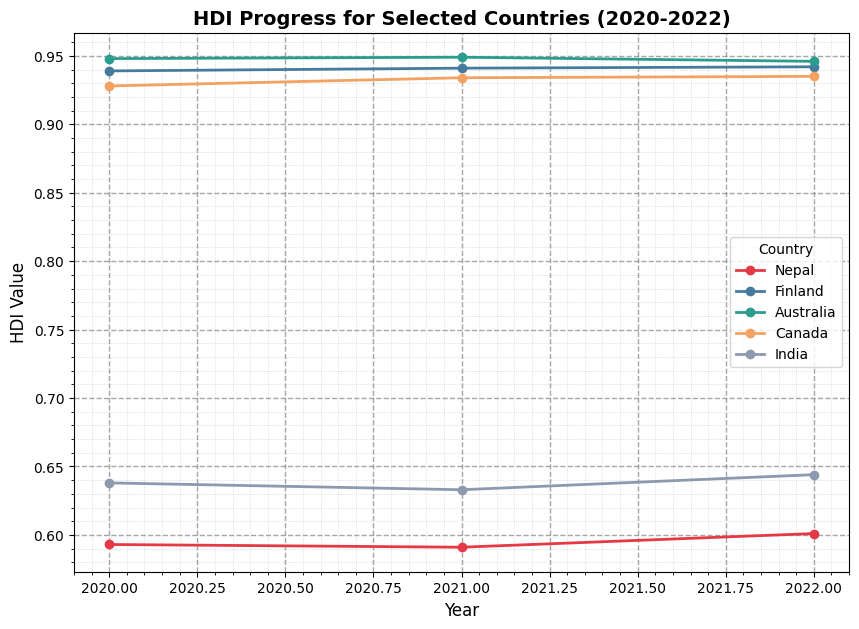

In [14]:
"""
3. Visualization Tasks:
HDI Trend Visualization for Selected Countries (2020-2022)

This script generates a line chart showing the Human Development Index (HDI)
for five chosen countries over the years 2020, 2021, and 2022. Key features include:

- Distinct colors for each country for better clarity
- Markers highlighting each data point
- Custom grid lines for easier readability
- Axis labels, legend, and descriptive title
"""

import matplotlib.pyplot as plt

# Filter data for each country (Nepal, Finland, Australia, Canada, India)
indonesia_df = filtered_dataset[filtered_dataset['country']=='Nepal']
dominica_df = filtered_dataset[filtered_dataset['country']=='Finland']
ecuador_df = filtered_dataset[filtered_dataset['country']=='Australia']
china_df = filtered_dataset[filtered_dataset['country']=='Canada']
fiji_df = filtered_dataset[filtered_dataset['country']=='India']

# Set up the figure
plt.figure(figsize=(10,7))
plt.title("HDI Progress for Selected Countries (2020-2022)", fontsize=14, fontweight='bold')

# Plot HDI lines with new, distinct colors
plt.plot(indonesia_df['year'].values, indonesia_df['hdi'], marker='o', c='#E63946', label="Nepal", linewidth=2)  # red
plt.plot(dominica_df['year'].values, dominica_df['hdi'], marker='o', c='#457B9D', label="Finland", linewidth=2)    # blue
plt.plot(ecuador_df['year'].values, ecuador_df['hdi'], marker='o', c='#2A9D8F', label="Australia", linewidth=2)       # teal
plt.plot(china_df['year'].values, china_df['hdi'], marker='o', c='#F4A261', label="Canada", linewidth=2)            # orange
plt.plot(fiji_df['year'].values, fiji_df['hdi'], marker='o', c='#8D99AE', label="India", linewidth=2)               # gray

# Configure grid lines
plt.grid(True, which='major', linestyle='--', linewidth=1, color='gray', alpha=0.7)  # major grid
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.4)  # minor grid

# Axis labels and legend
plt.xlabel("Year", fontsize=12)
plt.ylabel("HDI Value", fontsize=12)
plt.legend(title="Country")
plt.show()


In [15]:
"""
Assign Regions to Countries Safely

This code maps each country in the dataset to its respective region
(South Asia, Europe, Africa, Americas, Asia, Oceania) using ISO3 country codes.
It ensures that assignment is safe by creating a copy of the dataset slice,
preventing SettingWithCopyWarning. Rows without a valid region are removed.
"""

# Make a safe copy to avoid SettingWithCopyWarning
filtered_dataset = filtered_dataset.copy()

# Define mapping of ISO3 country codes to regions
region_map = {
    # South Asia
    'AFG': 'South Asia', 'BGD': 'South Asia', 'BTN': 'South Asia',
    'IND': 'South Asia', 'MDV': 'South Asia', 'NPL': 'South Asia',
    'PAK': 'South Asia', 'LKA': 'South Asia',

    # Europe
    'ALB': 'Europe', 'AND': 'Europe', 'AUT': 'Europe', 'BEL': 'Europe',
    'BIH': 'Europe', 'BGR': 'Europe', 'HRV': 'Europe', 'CYP': 'Europe',
    'CZE': 'Europe', 'DNK': 'Europe', 'EST': 'Europe', 'FIN': 'Europe',
    'FRA': 'Europe', 'DEU': 'Europe', 'GRC': 'Europe', 'HUN': 'Europe',
    'ISL': 'Europe', 'IRL': 'Europe', 'ITA': 'Europe', 'LVA': 'Europe',
    'LIE': 'Europe', 'LTU': 'Europe', 'LUX': 'Europe', 'MLT': 'Europe',
    'MCO': 'Europe', 'MNE': 'Europe', 'NLD': 'Europe', 'MKD': 'Europe',
    'NOR': 'Europe', 'POL': 'Europe', 'PRT': 'Europe', 'ROU': 'Europe',
    'RUS': 'Europe', 'SMR': 'Europe', 'SRB': 'Europe', 'SVK': 'Europe',
    'SVN': 'Europe', 'ESP': 'Europe', 'SWE': 'Europe', 'CHE': 'Europe',
    'UKR': 'Europe', 'GBR': 'Europe',

    # Africa
    'DZA': 'Africa', 'AGO': 'Africa', 'BEN': 'Africa', 'BWA': 'Africa',
    'BFA': 'Africa', 'BDI': 'Africa', 'CPV': 'Africa', 'CMR': 'Africa',
    'CAF': 'Africa', 'TCD': 'Africa', 'COM': 'Africa', 'COG': 'Africa',
    'COD': 'Africa', 'CIV': 'Africa', 'DJI': 'Africa', 'EGY': 'Africa',
    'GNQ': 'Africa', 'ERI': 'Africa', 'SWZ': 'Africa', 'ETH': 'Africa',
    'GAB': 'Africa', 'GMB': 'Africa', 'GHA': 'Africa', 'GIN': 'Africa',
    'GNB': 'Africa', 'KEN': 'Africa', 'LSO': 'Africa', 'LBR': 'Africa',
    'LBY': 'Africa', 'MDG': 'Africa', 'MWI': 'Africa', 'MLI': 'Africa',
    'MRT': 'Africa', 'MUS': 'Africa', 'MAR': 'Africa', 'MOZ': 'Africa',
    'NAM': 'Africa', 'NER': 'Africa', 'NGA': 'Africa', 'RWA': 'Africa',
    'STP': 'Africa', 'SEN': 'Africa', 'SYC': 'Africa', 'SLE': 'Africa',
    'SOM': 'Africa', 'ZAF': 'Africa', 'SSD': 'Africa', 'SDN': 'Africa',
    'TZA': 'Africa', 'TGO': 'Africa', 'TUN': 'Africa', 'UGA': 'Africa',
    'ZMB': 'Africa', 'ZWE': 'Africa',

    # Americas
    'ATG': 'Americas', 'ARG': 'Americas', 'BHS': 'Americas', 'BRB': 'Americas',
    'BLZ': 'Americas', 'BOL': 'Americas', 'BRA': 'Americas', 'CAN': 'Americas',
    'CHL': 'Americas', 'COL': 'Americas', 'CRI': 'Americas', 'CUB': 'Americas',
    'DMA': 'Americas', 'DOM': 'Americas', 'ECU': 'Americas', 'SLV': 'Americas',
    'GRD': 'Americas', 'GTM': 'Americas', 'GUY': 'Americas', 'HTI': 'Americas',
    'HND': 'Americas', 'JAM': 'Americas', 'MEX': 'Americas', 'NIC': 'Americas',
    'PAN': 'Americas', 'PRY': 'Americas', 'PER': 'Americas', 'KNA': 'Americas',
    'LCA': 'Americas', 'VCT': 'Americas', 'SUR': 'Americas', 'TTO': 'Americas',
    'USA': 'Americas', 'URY': 'Americas', 'VEN': 'Americas',

    # Asia (excluding South Asia)
    'ARM': 'Asia', 'AZE': 'Asia', 'BHR': 'Asia', 'BRN': 'Asia', 'KHM': 'Asia',
    'CHN': 'Asia', 'GEO': 'Asia', 'HKG': 'Asia', 'IDN': 'Asia', 'IRN': 'Asia',
    'IRQ': 'Asia', 'ISR': 'Asia', 'JPN': 'Asia', 'JOR': 'Asia', 'KAZ': 'Asia',
    'KWT': 'Asia', 'KGZ': 'Asia', 'LAO': 'Asia', 'LBN': 'Asia', 'MYS': 'Asia',
    'MNG': 'Asia', 'MMR': 'Asia', 'PRK': 'Asia', 'OMN': 'Asia', 'PSE': 'Asia',
    'PHL': 'Asia', 'QAT': 'Asia', 'SAU': 'Asia', 'SGP': 'Asia', 'KOR': 'Asia',
    'SYR': 'Asia', 'TJK': 'Asia', 'THA': 'Asia', 'TLS': 'Asia', 'TUR': 'Asia',
    'TKM': 'Asia', 'ARE': 'Asia', 'UZB': 'Asia', 'VNM': 'Asia', 'YEM': 'Asia',

    # Oceania
    'AUS': 'Oceania', 'FJI': 'Oceania', 'KIR': 'Oceania', 'MHL': 'Oceania',
    'FSM': 'Oceania', 'NRU': 'Oceania', 'NZL': 'Oceania', 'PLW': 'Oceania',
    'PNG': 'Oceania', 'WSM': 'Oceania', 'SLB': 'Oceania', 'TON': 'Oceania',
    'TUV': 'Oceania', 'VUT': 'Oceania'
}

# Map countries to their respective regions safely
filtered_dataset['Region'] = filtered_dataset['iso3'].map(region_map)

# Remove rows where region mapping is missing
filtered_dataset = filtered_dataset.dropna(subset=['Region'])


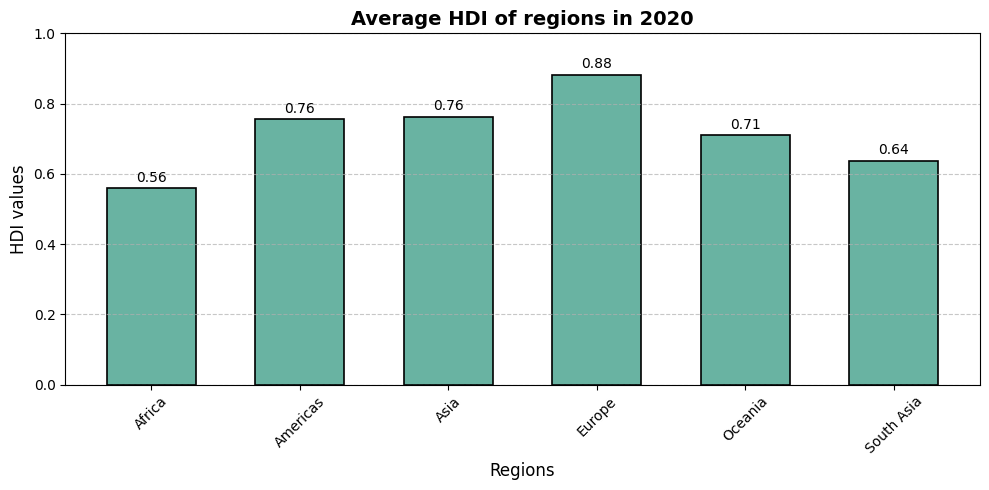

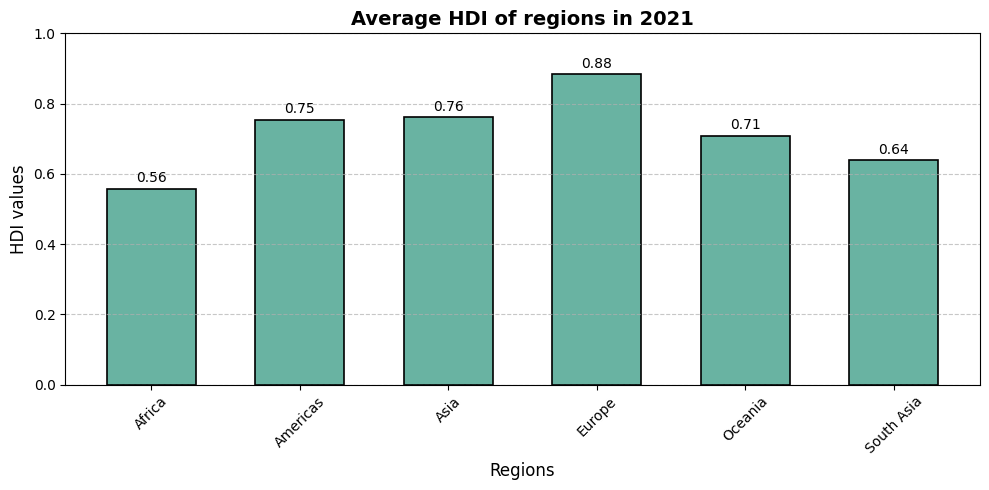

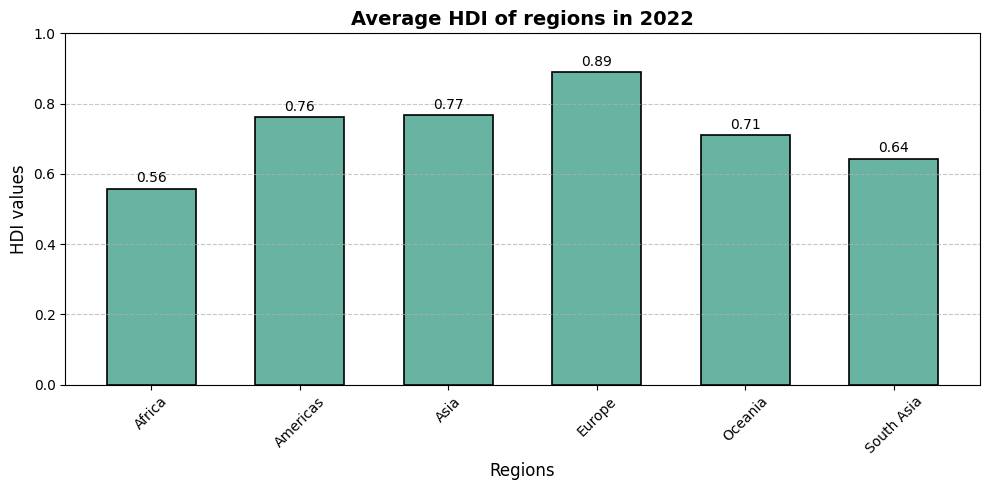

In [16]:
'''
• B. Generate Visualizations:
– Bar Chart: Average HDI by Region (2020–2022)
∗ Group the dataset by Region and Year.
∗ Compute the mean HDI for each region-year pair.
∗ Plot a bar chart comparing average HDI across regions for each year.
∗ Label axes clearly and include a descriptive title.
'''

# Function to plot bar graph for a specific year with improved design
def plotBar(x, y, year):
    """
    Plots a visually enhanced bar chart showing average HDI by region for a given year.

    Parameters:
    - x (Index or list): Region names
    - y (list or array): Average HDI values
    - year (int): Year for chart title
    """
    plt.figure(figsize=(10,5))

    # Bar design: color, edge, width
    bars = plt.bar(x, y, color='#69b3a2', edgecolor='black', linewidth=1.2, width=0.6)

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}',
                 ha='center', va='bottom', fontsize=10)

    # Grid and labels
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # horizontal dashed grid
    plt.title(f"Average HDI of regions in {year}", fontsize=14, fontweight='bold')
    plt.xlabel("Regions", fontsize=12)
    plt.ylabel("HDI values", fontsize=12)
    plt.xticks(rotation=45)  # rotate labels for clarity
    plt.ylim(0, 1)  # HDI range

    plt.tight_layout()
    plt.show()


# Filtering dataset by years
dataset_2020 = filtered_dataset[filtered_dataset['year'] == 2020]
dataset_2021 = filtered_dataset[filtered_dataset['year'] == 2021]
dataset_2022 = filtered_dataset[filtered_dataset['year'] == 2022]

# Calculating average HDI for each year
average_hdi_2020 = dataset_2020.groupby('Region')['hdi'].mean()
average_hdi_2021 = dataset_2021.groupby('Region')['hdi'].mean()
average_hdi_2022 = dataset_2022.groupby('Region')['hdi'].mean()

# Plotting bar graphs for every year
plotBar(average_hdi_2020.index, average_hdi_2020.values, 2020)
plotBar(average_hdi_2021.index, average_hdi_2021.values, 2021)
plotBar(average_hdi_2022.index, average_hdi_2022.values, 2022)


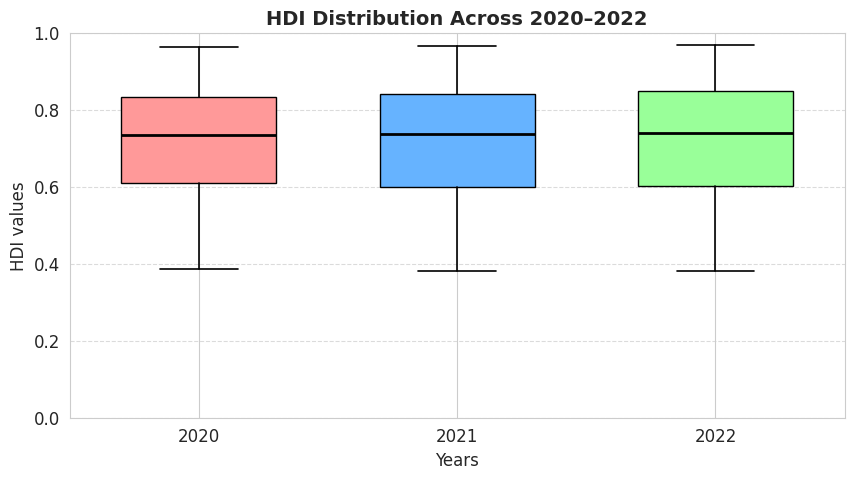

In [33]:
import matplotlib.pyplot as plt

# Colors for each year
colors = ['#FF9999', '#66B3FF', '#99FF99']  # 2020=red, 2021=blue, 2022=green

plt.figure(figsize=(10,5))

# Create the boxplot (straight boxes)
box = plt.boxplot(
    [
        dataset_2020['hdi'].dropna(),
        dataset_2021['hdi'].dropna(),
        dataset_2022['hdi'].dropna()
    ],
    patch_artist=True,       # fill boxes with color
    notch=False,             # straight boxes (remove notches)
    labels=['2020','2021','2022'],
    widths=0.6,              # box width
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, linestyle='none')
)

# Assign different colors to each box
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Titles and labels
plt.title("HDI Distribution Across 2020–2022", fontsize=14, fontweight='bold')
plt.xlabel("Years", fontsize=12)
plt.ylabel("HDI values", fontsize=12)

# Grid styling
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1)  # HDI range

plt.show()


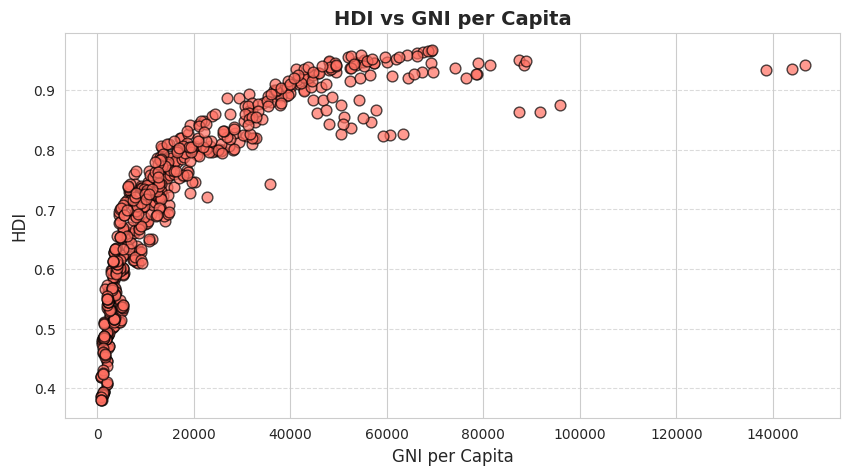

In [18]:
'''
Scatter Plot: Relationship Between HDI and GNI per Capita
• Verify that the dataset contains a column for GNI per Capita.
• If available, plot HDI (dependent variable) against GNI per Capita (independent variable).
• Customize the plot with color, size, and markers for clarity.
• Include axis labels and a descriptive title.
'''

import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of HDI vs. GNI per Capita
plt.figure(figsize=(10,5))

# Using Seaborn style for modern look
sns.set_style("whitegrid")

# Scatter points with color, size, and transparency
plt.scatter(
    filtered_dataset['gross_inc_percap'],
    filtered_dataset['hdi'],
    c='#FF6F61',    # coral color
    s=60,           # marker size
    alpha=0.7,      # transparency for overlapping points
    edgecolor='black'  # black edge around markers
)

# Titles and labels
plt.title("HDI vs GNI per Capita", fontsize=14, fontweight='bold')
plt.xlabel("GNI per Capita", fontsize=12)
plt.ylabel("HDI", fontsize=12)

# Optional: add a horizontal grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


# PROBLEM **2**

In [19]:
"""
Problem 2: Beginner-Level HDI Analysis for South Asia

This script performs basic exploration of the Human Development Index (HDI) dataset:
1. Reads the dataset from a CSV file.
2. Filters the dataset to include only South Asian countries.
3. Handles missing values by backfilling.
4. Saves the filtered dataset to a new CSV file for further analysis.
"""
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ========================
# TASK 1: South Asia Subset
# ========================

# Read the data from CSV file
print("Step 1: Reading the data file...")
# Read the CSV file with a different encoding to avoid UnicodeDecodeError
df = pd.read_csv("Human_Development_Index_Dataset.csv", encoding='latin1')


# List of South Asian countries
south_asia_countries = ["Afghanistan", "Bangladesh", "Bhutan", "India",
                        "Maldives", "Nepal", "Pakistan", "Sri Lanka"]

# Filter the data to include only South Asian countries
print("Step 2: Filtering for South Asian countries...")
south_asia_data = df[df['country'].isin(south_asia_countries)]

# Fill missing values with the next available value
south_asia_data = south_asia_data.fillna(method='bfill')

# Save to a new CSV file
south_asia_data.to_csv("HDI_southasia.csv", index=False)
print("Step 3: Saved South Asia data to 'HDI_southasia.csv'")


Step 1: Reading the data file...
Step 2: Filtering for South Asian countries...
Step 3: Saved South Asia data to 'HDI_southasia.csv'


/tmp/ipython-input-1572891682.py:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  south_asia_data = south_asia_data.fillna(method='bfill')


Part 2: Calculating Composite Scores and Rankings...

Composite Score Ranking:
country
Maldives       4154.252676
Sri Lanka      2502.612949
Bhutan         1878.321569
Pakistan       1184.282350
India          1151.101140
Bangladesh     1042.583232
Nepal           779.209282
Afghanistan     555.454413
Name: Composite_Score, dtype: float64

HDI Ranking:
country
Sri Lanka      0.715606
Maldives       0.668182
Bhutan         0.602697
India          0.541485
Bangladesh     0.531303
Nepal          0.504242
Pakistan       0.472545
Afghanistan    0.401030
Name: hdi, dtype: float64


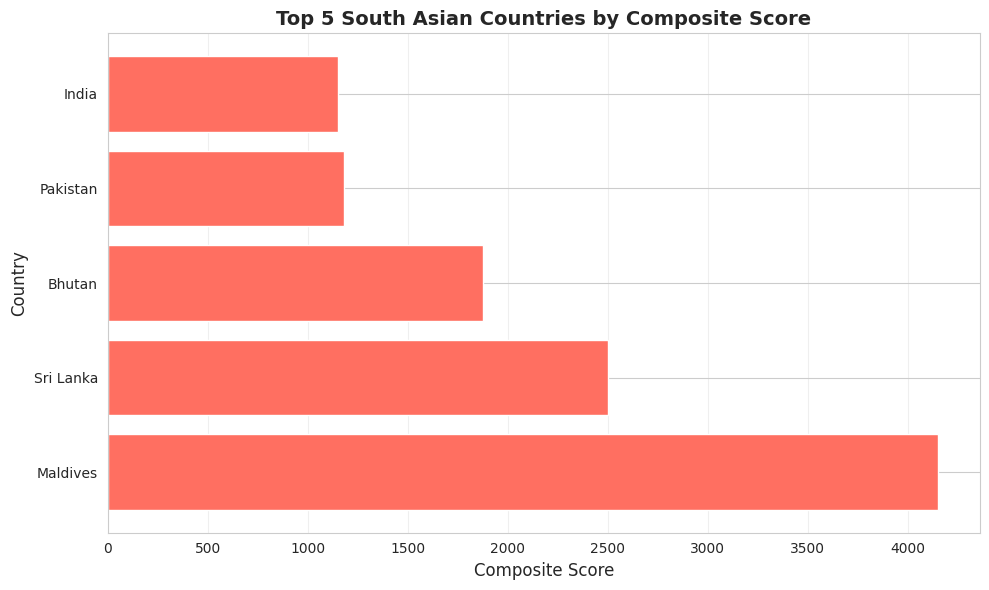

In [20]:
"""
Problem 2, Part 2: Composite Score Analysis and Rankings (Self-contained)

Objective:
- Filter the HDI dataset for South Asian countries.
- Calculate a simple Composite Score: 30% Life Expectancy + 30% GNI per Capita.
- Compute average Composite Score and HDI per country.
- Rank countries and visualize the top 5 by Composite Score.
"""

import matplotlib.pyplot as plt

print("Part 2: Calculating Composite Scores and Rankings...")

# List of South Asian countries
south_asia_countries = ["Afghanistan", "Bangladesh", "Bhutan", "India",
                        "Maldives", "Nepal", "Pakistan", "Sri Lanka"]

#Filter the cleaned HDI dataset and create an explicit copy
south_asia_df = south_asia_data.copy()

# Check if required columns exist
required_cols = ['life_expectancy', 'gross_inc_percap', 'hdi']
for col in required_cols:
    if col not in south_asia_df.columns:
        raise ValueError(f"Column '{col}' is missing from the dataset.")

# Compute Composite Score
south_asia_df['Composite_Score'] = (
    0.3 * south_asia_df['life_expectancy'] +
    0.3 * south_asia_df['gross_inc_percap']
)

# Compute average by country
composite_avg = south_asia_df.groupby('country')['Composite_Score'].mean()
hdi_avg = south_asia_df.groupby('country')['hdi'].mean()

# Rankings
composite_ranking = composite_avg.sort_values(ascending=False)
hdi_ranking = hdi_avg.sort_values(ascending=False)

# Display rankings
print("\nComposite Score Ranking:")
print(composite_ranking)
print("\nHDI Ranking:")
print(hdi_ranking)

# Bar chart for top 5 countries by Composite Score
plt.figure(figsize=(10,6))
top5_countries = composite_ranking.head(5).index
top5_scores = composite_ranking.head(5).values
plt.barh(top5_countries, top5_scores, color='#FF6F61')  # Coral-colored bars
plt.title("Top 5 South Asian Countries by Composite Score", fontsize=14, fontweight='bold')
plt.xlabel("Composite Score", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Part 3: Detecting outliers...
Number of outlier entries: 19
Outlier countries: ['Maldives' 'Sri Lanka']


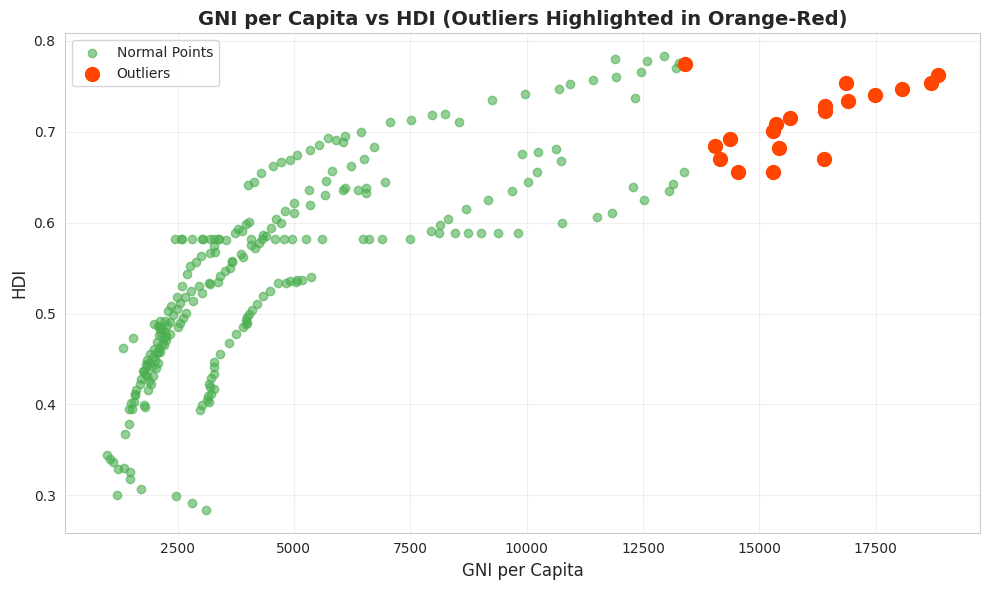

In [21]:
"""
Problem 2, Part 3: Detecting HDI and GNI Outliers

Objective:
- Use the IQR (Interquartile Range) method to identify outliers in HDI and GNI per Capita.
- Highlight normal and outlier points on a scatter plot with distinct colors.
- Facilitate visual inspection of anomalies in South Asian countries.
"""

print("Part 3: Detecting outliers...")

# Calculate IQR for HDI
q1_hdi = south_asia_df['hdi'].quantile(0.25)
q3_hdi = south_asia_df['hdi'].quantile(0.75)
iqr_hdi = q3_hdi - q1_hdi
hdi_bounds = (q1_hdi - 1.5*iqr_hdi, q3_hdi + 1.5*iqr_hdi)

# Calculate IQR for GNI per Capita
q1_gni = south_asia_df['gross_inc_percap'].quantile(0.25)
q3_gni = south_asia_df['gross_inc_percap'].quantile(0.75)
iqr_gni = q3_gni - q1_gni
gni_bounds = (q1_gni - 1.5*iqr_gni, q3_gni + 1.5*iqr_gni)

# Identify outlier rows
outliers_df = south_asia_df[
    (south_asia_df['hdi'] < hdi_bounds[0]) | (south_asia_df['hdi'] > hdi_bounds[1]) |
    (south_asia_df['gross_inc_percap'] < gni_bounds[0]) | (south_asia_df['gross_inc_percap'] > gni_bounds[1])
]

print(f"Number of outlier entries: {len(outliers_df)}")
print("Outlier countries:", outliers_df['country'].unique())

# Scatter plot highlighting outliers
plt.figure(figsize=(10,6))
plt.scatter(south_asia_df['gross_inc_percap'], south_asia_df['hdi'], alpha=0.6, label='Normal Points', color='#4CAF50')  # green points
if len(outliers_df) > 0:
    plt.scatter(outliers_df['gross_inc_percap'], outliers_df['hdi'], color='#FF4500', s=100, label='Outliers')  # orange-red points
plt.title("GNI per Capita vs HDI (Outliers Highlighted in Orange-Red)", fontsize=14, fontweight='bold')
plt.xlabel("GNI per Capita", fontsize=12)
plt.ylabel("HDI", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Part 4: Exploring metric relationships with HDI...
Life Expectancy vs HDI correlation: 0.916
Gender Development vs HDI correlation: 0.852
Stronger predictor of HDI: Life Expectancy


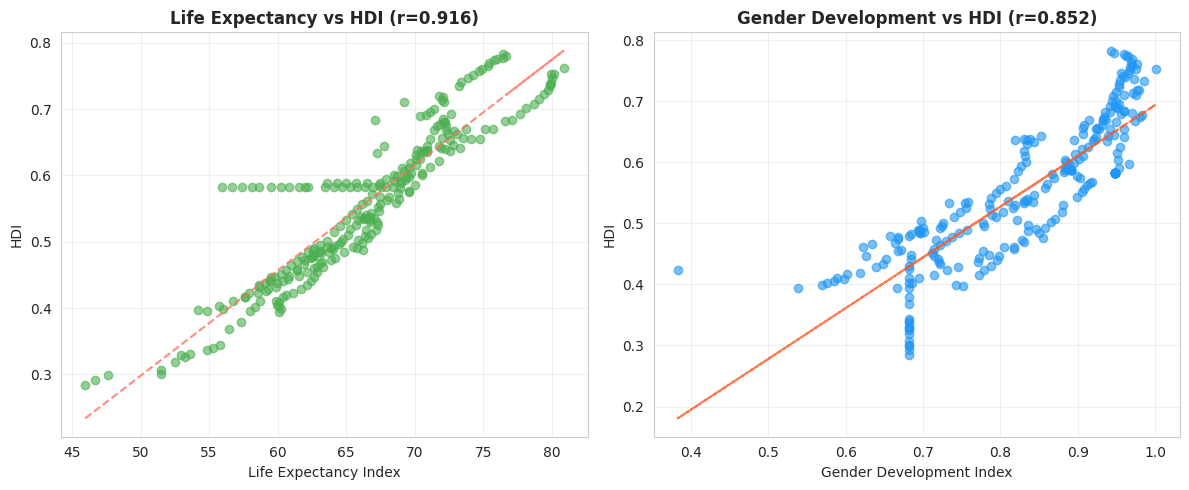

In [22]:
"""
Problem 2, Part 4: Investigating HDI Relationships with Key Metrics

Goal:
- Analyze how Life Expectancy and Gender Development indices correlate with HDI in South Asia.
- Calculate Pearson correlations to determine which metric is a stronger predictor.
- Visualize relationships using scatter plots with fitted trendlines.
"""

import numpy as np

print("Part 4: Exploring metric relationships with HDI...")

# Pearson correlations
corr_life = south_asia_df['life_expectancy'].corr(south_asia_df['hdi'])
corr_gender = south_asia_df['gender_development'].corr(south_asia_df['hdi'])
print(f"Life Expectancy vs HDI correlation: {corr_life:.3f}")
print(f"Gender Development vs HDI correlation: {corr_gender:.3f}")

stronger_metric = "Life Expectancy" if abs(corr_life) > abs(corr_gender) else "Gender Development"
print(f"Stronger predictor of HDI: {stronger_metric}")

# Scatter plots with trendlines
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Life Expectancy vs HDI
ax1.scatter(south_asia_df['life_expectancy'], south_asia_df['hdi'], alpha=0.6, color='#4CAF50')  # green points
z1 = np.polyfit(south_asia_df['life_expectancy'], south_asia_df['hdi'], 1)
ax1.plot(south_asia_df['life_expectancy'], np.poly1d(z1)(south_asia_df['life_expectancy']), color='#FF6F61', linestyle='--', alpha=0.8)  # coral trendline
ax1.set_title(f"Life Expectancy vs HDI (r={corr_life:.3f})", fontsize=12, fontweight='bold')
ax1.set_xlabel("Life Expectancy Index")
ax1.set_ylabel("HDI")
ax1.grid(alpha=0.3)

# Gender Development vs HDI
ax2.scatter(south_asia_df['gender_development'], south_asia_df['hdi'], alpha=0.6, color='#2196F3')  # blue points
z2 = np.polyfit(south_asia_df['gender_development'], south_asia_df['hdi'], 1)
ax2.plot(south_asia_df['gender_development'], np.poly1d(z2)(south_asia_df['gender_development']), color='#FF5722', linestyle='--', alpha=0.8)  # orange trendline
ax2.set_title(f"Gender Development vs HDI (r={corr_gender:.3f})", fontsize=12, fontweight='bold')
ax2.set_xlabel("Gender Development Index")
ax2.set_ylabel("HDI")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Part 5: Performing GNI-HDI gap analysis...


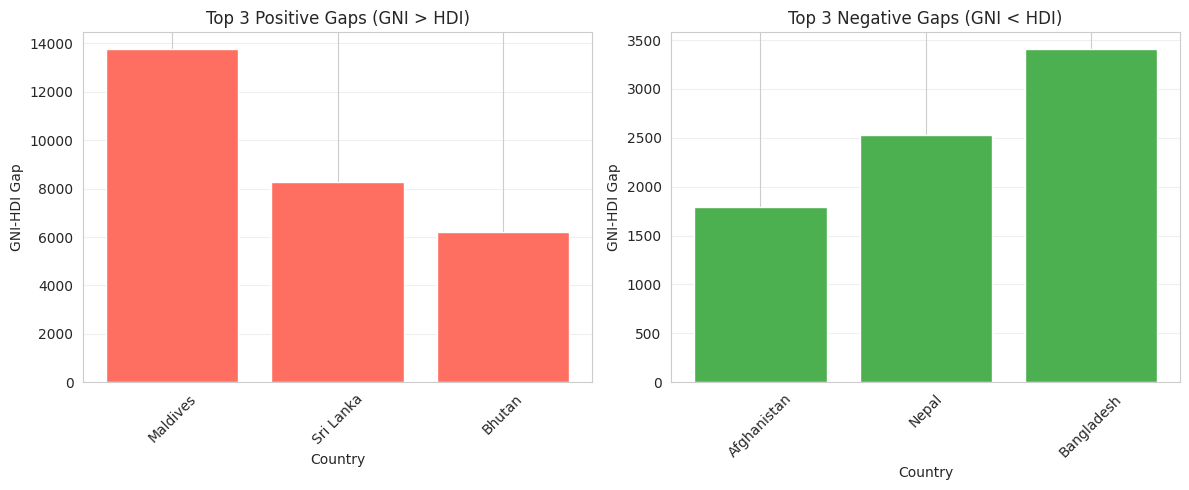

In [23]:
"""
Problem 2, Part 5: GNI-HDI Gap Analysis with Enhanced Visualization

Goal:
- Calculate the difference between Gross National Income per Capita and HDI for each country.
- Highlight countries where GNI significantly exceeds or falls behind HDI.
- Display the top 3 countries with the largest positive and negative gaps using visually distinct bar colors.
"""

print("Part 5: Performing GNI-HDI gap analysis...")

# Compute GNI-HDI gap
south_asia_df['GNI_HDI_Gap'] = south_asia_df['gross_inc_percap'] - south_asia_df['hdi']

# Average gap by country
gap_avg = south_asia_df.groupby('country')['GNI_HDI_Gap'].mean()
gap_top = gap_avg.sort_values(ascending=False)
gap_bottom = gap_avg.sort_values(ascending=True)

# Visualization
plt.figure(figsize=(12,5))

# Top 3 positive gaps (GNI > HDI)
plt.subplot(1,2,1)
plt.bar(gap_top.head(3).index, gap_top.head(3).values, color='#FF6F61')  # coral
plt.title("Top 3 Positive Gaps (GNI > HDI)")
plt.xlabel("Country")
plt.ylabel("GNI-HDI Gap")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Top 3 negative gaps (GNI < HDI)
plt.subplot(1,2,2)
plt.bar(gap_bottom.head(3).index, gap_bottom.head(3).values, color='#4CAF50')  # green
plt.title("Top 3 Negative Gaps (GNI < HDI)")
plt.xlabel("Country")
plt.ylabel("GNI-HDI Gap")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# **PROBLEM 3**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plot appearance
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("="*70)
print("REGIONAL HDI ANALYSIS")
print("COMPARING SOUTH ASIA AND MIDDLE EAST (2020-2022)")
print("="*70)

"""
Load HDI dataset:
- Try to read the preprocessed file from Problem 1B.
- If not found, read the original dataset and filter years 2020-2022.
- Perform basic cleaning, type conversion, and handle encoding issues.
"""
print("\nLoading dataset from Problem 1B...")

try:
    # Attempt to read preprocessed dataset
    hdi_2020_2022 = pd.read_csv('HDI_problem1B.csv')
    print(f"Dataset loaded successfully. Shape: {hdi_2020_2022.shape}")
except FileNotFoundError:
    print("HDI_problem1B.csv not found. Preparing data from original dataset...")
    # Read original dataset with encoding to avoid Unicode errors
    df = pd.read_csv('Human_Development_Index_Dataset.csv', encoding='latin1')

    # Keep only rows for years 2020, 2021, 2022
    hdi_2020_2022 = df[df['year'].isin([2020, 2021, 2022])].copy()

    # Remove rows missing essential columns
    hdi_2020_2022 = hdi_2020_2022.dropna(subset=['hdi', 'country', 'year'])

    # Convert numeric columns to proper types, removing non-numeric symbols
    for col in ['hdi', 'life_expectancy', 'gross_inc_percap', 'gender_development']:
        if col in hdi_2020_2022.columns and hdi_2020_2022[col].dtype == 'object':
            hdi_2020_2022[col] = pd.to_numeric(
                hdi_2020_2022[col].astype(str).str.replace('-', ''),
                errors='coerce'
            )
    print(f"Dataset prepared. Shape after cleaning: {hdi_2020_2022.shape}")

# Display first few rows to confirm
print("\nPreview of the dataset:")
print(hdi_2020_2022.head())


REGIONAL HDI ANALYSIS
COMPARING SOUTH ASIA AND MIDDLE EAST (2020-2022)

Loading dataset from Problem 1B...
HDI_problem1B.csv not found. Preparing data from original dataset...
Dataset prepared. Shape after cleaning: (610, 30)

Preview of the dataset:
    Unnamed: 0 iso3      country  year    hdi  life_expectancy  pop_millions  \
30          31  AFG  Afghanistan  2020  0.488           62.575     38.972231   
31          32  AFG  Afghanistan  2021  0.473           61.982     40.099462   
32          33  AFG  Afghanistan  2022  0.462           62.879     41.128771   
63          64  ALB      Albania  2020  0.784           76.989      2.866849   
64          65  ALB      Albania  2021  0.785           76.463      2.854710   

       hdi_f     hdi_m  life_expec_f  ...  gender_development  \
30  0.381373  0.548741        65.432  ...               0.695   
31  0.379129  0.528559        65.279  ...               0.717   
32  0.332443  0.534145        66.213  ...               0.622   
63  0.77

In [25]:
"""
Task 1: Regional Data Extraction for HDI Analysis

Purpose:
- Separate the main HDI dataset into two regional subsets:
  1. South Asia
  2. Middle East
- Save these subsets as CSV files for subsequent analysis.

Steps:
- Define lists of countries for South Asia and the Middle East.
- Filter the main dataset to include only the countries in each list.
- Display the shape of each subset and the countries included.
- Save the resulting subsets to CSV files.
"""
print("\n" + "="*60)
print("TASK 1: REGIONAL DATA EXTRACTION")
print("="*60)

# List of South Asian countries for the analysis
south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

# List of Middle East countries for the analysis
middle_east_countries = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
    "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
    "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"
]

# Create South Asia subset
south_asia_df = hdi_2020_2022[hdi_2020_2022['country'].isin(south_asia_countries)].copy()
print(f"South Asia subset shape: {south_asia_df.shape}")
print(f"Countries included: {south_asia_df['country'].unique()}")

# Create Middle East subset
middle_east_df = hdi_2020_2022[hdi_2020_2022['country'].isin(middle_east_countries)].copy()
print(f"Middle East subset shape: {middle_east_df.shape}")
print(f"Countries included: {middle_east_df['country'].unique()}")

# Save subsets as CSV files for later use
south_asia_df.to_csv('HDI_SouthAsia_2020_2022.csv', index=False)
middle_east_df.to_csv('HDI_MiddleEast_2020_2022.csv', index=False)
print("\nRegional subsets saved successfully:")
print("- HDI_SouthAsia_2020_2022.csv")
print("- HDI_MiddleEast_2020_2022.csv")



TASK 1: REGIONAL DATA EXTRACTION
South Asia subset shape: (24, 30)
Countries included: ['Afghanistan' 'Bangladesh' 'Bhutan' 'India' 'Maldives' 'Nepal' 'Pakistan'
 'Sri Lanka']
Middle East subset shape: (33, 30)
Countries included: ['Bahrain' 'Iraq' 'Israel' 'Jordan' 'Kuwait' 'Lebanon' 'Oman' 'Qatar'
 'Saudi Arabia' 'United Arab Emirates' 'Yemen']

Regional subsets saved successfully:
- HDI_SouthAsia_2020_2022.csv
- HDI_MiddleEast_2020_2022.csv


In [26]:
"""
Task 2: Descriptive Statistics for Regional HDI

Purpose:
- Calculate yearly and overall HDI statistics for South Asia and Middle East.
- Provide mean, standard deviation, and count of HDI values.
- Compare average HDI between the two regions to identify which region performs better.

Steps:
- Group South Asia and Middle East datasets by year and compute mean, std, and count.
- Calculate overall HDI mean and standard deviation for each region.
- Compare regional averages and display the difference.
"""
print("\n" + "="*60)
print("TASK 2: DESCRIPTIVE STATISTICS")
print("="*60)

# South Asia: Yearly HDI statistics
print("\n--- SOUTH ASIA ---")
south_asia_stats = south_asia_df.groupby('year')['hdi'].agg(['mean', 'std', 'count']).round(3)
print("HDI Statistics by Year:")
print(south_asia_stats)

# South Asia: Overall mean and standard deviation
south_asia_mean = south_asia_df['hdi'].mean()
south_asia_std = south_asia_df['hdi'].std()
print(f"\nOverall (2020-2022):")
print(f"Mean HDI: {south_asia_mean:.3f}")
print(f"Std Dev: {south_asia_std:.3f}")

# Middle East: Yearly HDI statistics
print("\n--- MIDDLE EAST ---")
middle_east_stats = middle_east_df.groupby('year')['hdi'].agg(['mean', 'std', 'count']).round(3)
print("HDI Statistics by Year:")
print(middle_east_stats)

# Middle East: Overall mean and standard deviation
middle_east_mean = middle_east_df['hdi'].mean()
middle_east_std = middle_east_df['hdi'].std()
print(f"\nOverall (2020-2022):")
print(f"Mean HDI: {middle_east_mean:.3f}")
print(f"Std Dev: {middle_east_std:.3f}")

# Comparison of average HDI between regions
print("\n--- COMPARISON ---")
print(f"Middle East has {'higher' if middle_east_mean > south_asia_mean else 'lower'} average HDI")
print(f"Difference: {abs(middle_east_mean - south_asia_mean):.3f}")



TASK 2: DESCRIPTIVE STATISTICS

--- SOUTH ASIA ---
HDI Statistics by Year:
       mean    std  count
year                     
2020  0.638  0.097      8
2021  0.639  0.104      8
2022  0.643  0.107      8

Overall (2020-2022):
Mean HDI: 0.640
Std Dev: 0.098

--- MIDDLE EAST ---
HDI Statistics by Year:
       mean    std  count
year                     
2020  0.788  0.143     11
2021  0.787  0.146     11
2022  0.792  0.148     11

Overall (2020-2022):
Mean HDI: 0.789
Std Dev: 0.141

--- COMPARISON ---
Middle East has higher average HDI
Difference: 0.149



TASK 3: TOP AND BOTTOM HDI PERFORMERS

--- SOUTH ASIA ---
Top 3 countries:
  Sri Lanka: HDI = 0.780
  Maldives: HDI = 0.751
  Bhutan: HDI = 0.678

Bottom 3 countries:
  Afghanistan: HDI = 0.474
  Pakistan: HDI = 0.538
  Nepal: HDI = 0.595

--- MIDDLE EAST ---
Top 3 countries:
  United Arab Emirates: HDI = 0.933
  Israel: HDI = 0.911
  Bahrain: HDI = 0.885

Bottom 3 countries:
  Yemen: HDI = 0.426
  Iraq: HDI = 0.667
  Lebanon: HDI = 0.730

Generating bar chart visualization...


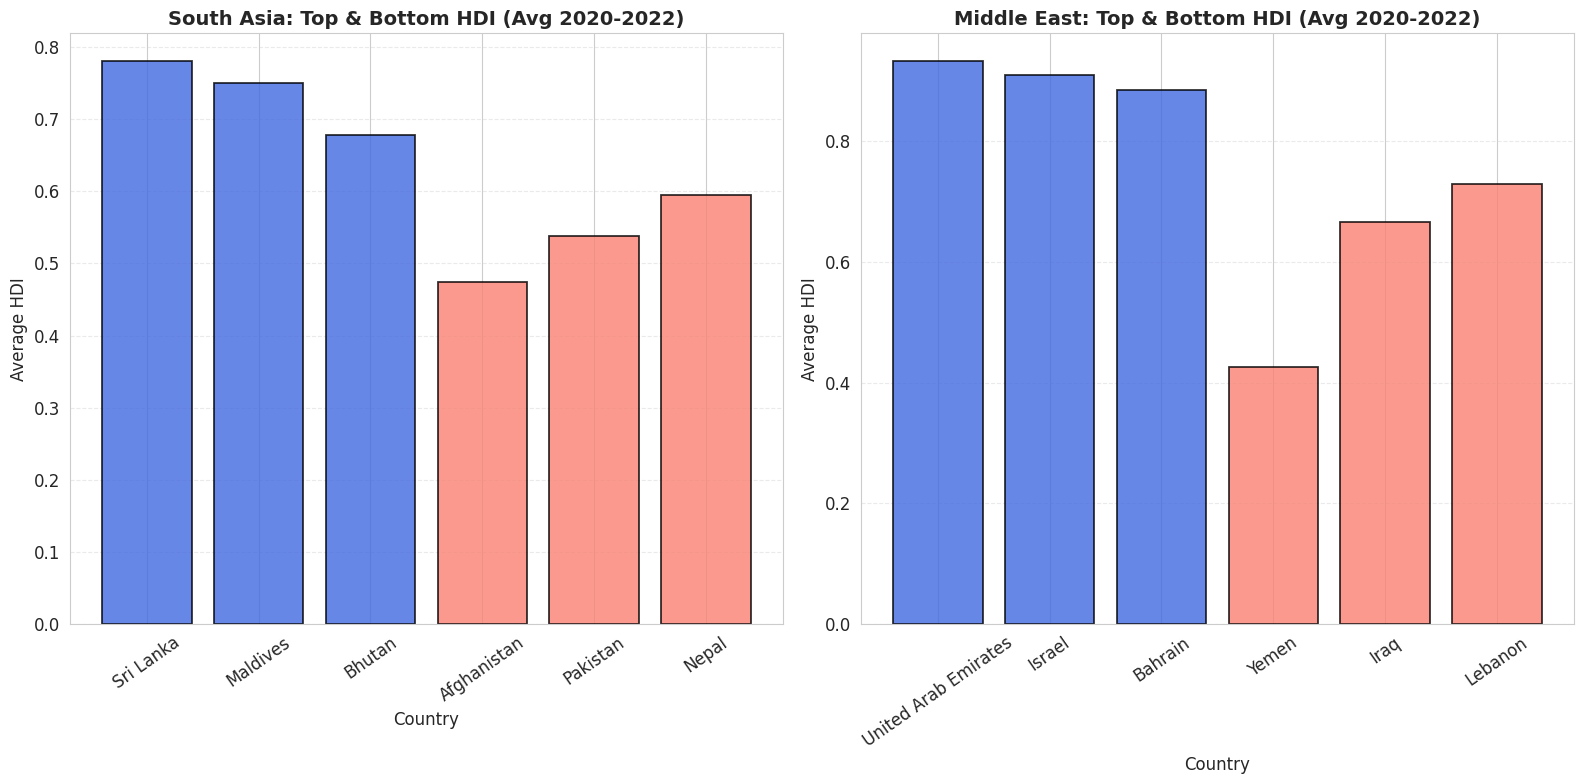

Saved: top_bottom_hdi_comparison.png


In [27]:
'''
TASK 3: Identify Top and Bottom HDI Countries
Region: South Asia vs Middle East (2020-2022)
Visualize top and bottom performers using bar charts with updated colors.
'''

print("\n" + "="*60)
print("TASK 3: TOP AND BOTTOM HDI PERFORMERS")
print("="*60)

# Function to extract top and bottom n countries by average HDI
def top_bottom_hdi(df, n=3):
    """
    Returns two DataFrames:
    - Top n countries based on mean HDI
    - Bottom n countries based on mean HDI
    """
    avg_hdi = df.groupby('country')['hdi'].mean().reset_index()
    top = avg_hdi.nlargest(n, 'hdi')
    bottom = avg_hdi.nsmallest(n, 'hdi')
    return top, bottom

# Get top/bottom performers for South Asia and Middle East
sa_top, sa_bottom = top_bottom_hdi(south_asia_df)
me_top, me_bottom = top_bottom_hdi(middle_east_df)

# Print South Asia results
print("\n--- SOUTH ASIA ---")
print("Top 3 countries:")
for _, row in sa_top.iterrows():
    print(f"  {row['country']}: HDI = {row['hdi']:.3f}")

print("\nBottom 3 countries:")
for _, row in sa_bottom.iterrows():
    print(f"  {row['country']}: HDI = {row['hdi']:.3f}")

# Print Middle East results
print("\n--- MIDDLE EAST ---")
print("Top 3 countries:")
for _, row in me_top.iterrows():
    print(f"  {row['country']}: HDI = {row['hdi']:.3f}")

print("\nBottom 3 countries:")
for _, row in me_bottom.iterrows():
    print(f"  {row['country']}: HDI = {row['hdi']:.3f}")

print("\nGenerating bar chart visualization...")

# Combine data for plotting
plot_df = pd.DataFrame({
    'Region': ['South Asia']*6 + ['Middle East']*6,
    'Country': list(sa_top['country']) + list(sa_bottom['country']) +
               list(me_top['country']) + list(me_bottom['country']),
    'HDI': list(sa_top['hdi']) + list(sa_bottom['hdi']) +
           list(me_top['hdi']) + list(me_bottom['hdi']),
    'Performance': ['Top']*3 + ['Bottom']*3 + ['Top']*3 + ['Bottom']*3
})

# Set up subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot South Asia
sa_plot = plot_df[plot_df['Region'] == 'South Asia']
colors_sa = ['royalblue']*3 + ['salmon']*3  # updated colors
axes[0].bar(sa_plot['Country'], sa_plot['HDI'], color=colors_sa, alpha=0.8, edgecolor='black', linewidth=1.3)
axes[0].set_title('South Asia: Top & Bottom HDI (Avg 2020-2022)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Country', fontsize=12)
axes[0].set_ylabel('Average HDI', fontsize=12)
axes[0].tick_params(axis='x', rotation=35)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Plot Middle East
me_plot = plot_df[plot_df['Region'] == 'Middle East']
colors_me = ['royalblue']*3 + ['salmon']*3  # updated colors
axes[1].bar(me_plot['Country'], me_plot['HDI'], color=colors_me, alpha=0.8, edgecolor='black', linewidth=1.3)
axes[1].set_title('Middle East: Top & Bottom HDI (Avg 2020-2022)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Country', fontsize=12)
axes[1].set_ylabel('Average HDI', fontsize=12)
axes[1].tick_params(axis='x', rotation=35)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('top_bottom_hdi_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top_bottom_hdi_comparison.png")



TASK 4: METRIC COMPARISONS
Metrics available in dataset: ['gender_development', 'life_expectancy', 'gross_inc_percap']

Regional Metric Comparison:
            Metric  South_Asia_Mean  South_Asia_Std  Middle_East_Mean  Middle_East_Std  Disparity
gender_development            0.881           0.096             0.897            0.155      0.015
   life_expectancy           70.970           5.431            75.855            5.064      4.885
  gross_inc_percap         7766.510        4682.052         37750.771        27569.596  29984.261

Metric with greatest disparity: gross_inc_percap
Disparity value: 29984.261


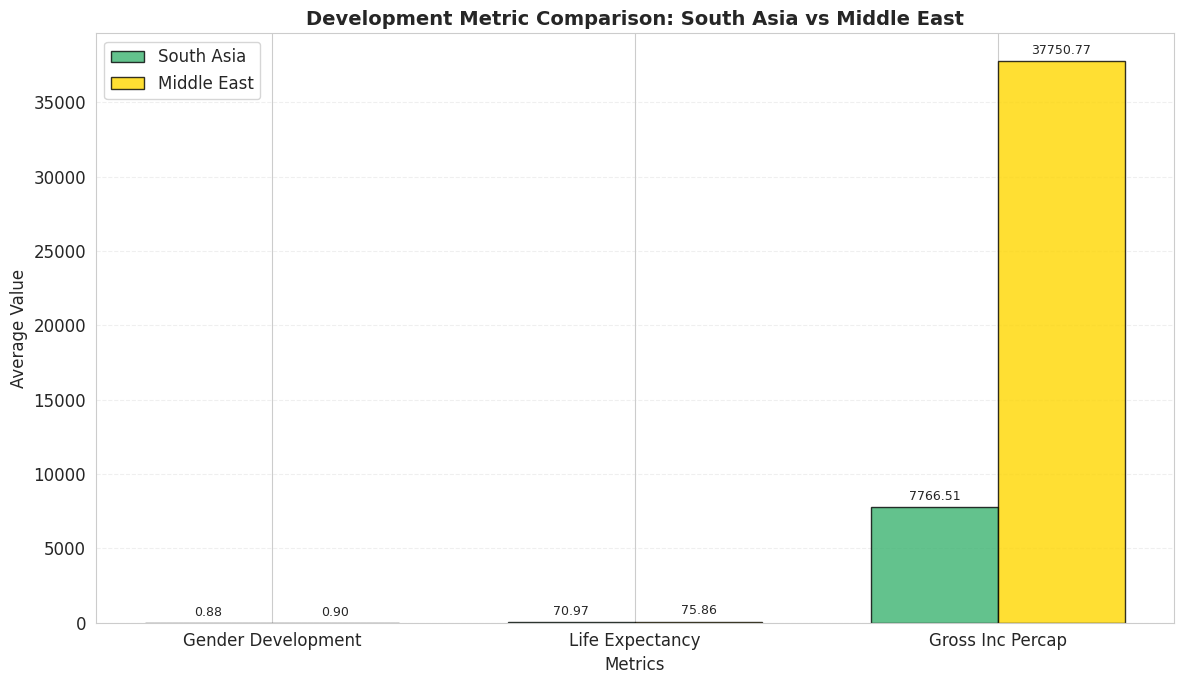

Saved: metric_comparison_regional.png


In [28]:
'''
TASK 4: Compare Key Development Metrics
Purpose:
- Evaluate and contrast key development metrics (Gender Development, Life Expectancy, Gross Income per Capita)
  between South Asia and Middle East for 2020-2022.
- Visualize regional differences using a grouped bar chart.
'''
print("\n" + "="*60)
print("TASK 4: METRIC COMPARISONS")
print("="*60)

# Select metrics to analyze
metrics_to_check = ['gender_development', 'life_expectancy', 'gross_inc_percap']
available_metrics = [m for m in metrics_to_check if m in hdi_2020_2022.columns]

print(f"Metrics available in dataset: {available_metrics}")

if available_metrics:
    # Initialize DataFrame for storing regional statistics
    regional_stats = pd.DataFrame()

    for metric in available_metrics:
        # Compute mean and standard deviation for South Asia
        sa_mean = south_asia_df[metric].mean()
        sa_std = south_asia_df[metric].std()

        # Compute mean and standard deviation for Middle East
        me_mean = middle_east_df[metric].mean()
        me_std = middle_east_df[metric].std()

        # Compute absolute difference between regions
        disparity = abs(me_mean - sa_mean)

        # Append results to DataFrame
        regional_stats = pd.concat([
            regional_stats,
            pd.DataFrame({
                'Metric': [metric],
                'South_Asia_Mean': [sa_mean],
                'South_Asia_Std': [sa_std],
                'Middle_East_Mean': [me_mean],
                'Middle_East_Std': [me_std],
                'Disparity': [disparity]
            })
        ], ignore_index=True)

    regional_stats = regional_stats.round(3)
    print("\nRegional Metric Comparison:")
    print(regional_stats.to_string(index=False))

    # Identify metric with largest disparity
    max_idx = regional_stats['Disparity'].idxmax()
    max_disparity_metric = regional_stats.loc[max_idx, 'Metric']
    max_disparity_value = regional_stats.loc[max_idx, 'Disparity']

    print(f"\nMetric with greatest disparity: {max_disparity_metric}")
    print(f"Disparity value: {max_disparity_value:.3f}")

    # --- Visualization: Grouped Bar Chart ---
    fig, ax = plt.subplots(figsize=(12, 7))

    x_pos = np.arange(len(available_metrics))
    bar_width = 0.35

    sa_values = regional_stats['South_Asia_Mean'].values
    me_values = regional_stats['Middle_East_Mean'].values

    # Plot bars with updated colors
    bars_sa = ax.bar(x_pos - bar_width/2, sa_values, bar_width,
                     label='South Asia', color='mediumseagreen', edgecolor='black', alpha=0.8)
    bars_me = ax.bar(x_pos + bar_width/2, me_values, bar_width,
                     label='Middle East', color='gold', edgecolor='black', alpha=0.8)

    # Function to annotate bars with values
    def label_bars(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    label_bars(bars_sa)
    label_bars(bars_me)

    # Configure axes and labels
    ax.set_xlabel('Metrics', fontsize=12)
    ax.set_ylabel('Average Value', fontsize=12)
    ax.set_title('Development Metric Comparison: South Asia vs Middle East',
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in available_metrics])
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig('metric_comparison_regional.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: metric_comparison_regional.png")
else:
    print("No metrics available for comparison.")



TASK 5: HDI DISPARITY ANALYSIS

--- SOUTH ASIA ---
HDI Range: 0.321
Coefficient of Variation (CV): 0.154

--- MIDDLE EAST ---
HDI Range: 0.513
Coefficient of Variation (CV): 0.179

--- COMPARISON ---
Middle East shows greater HDI variation (higher CV)


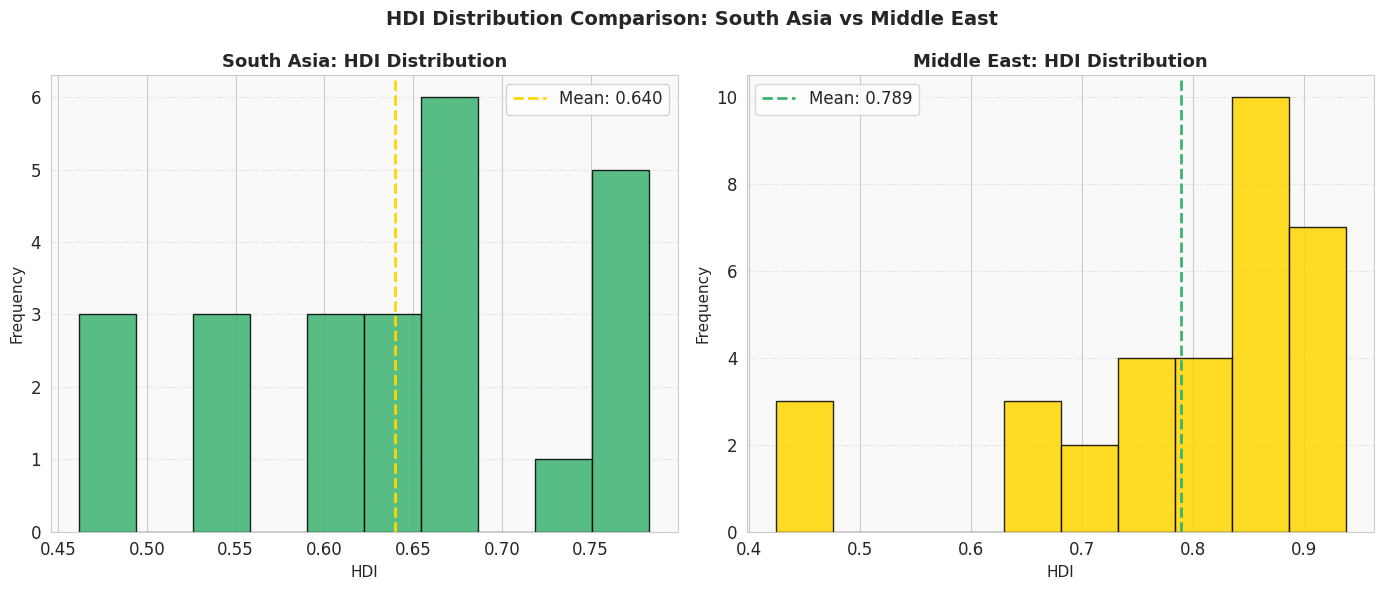

Saved: hdi_distribution_modern.png


In [29]:
'''
TASK 5: HDI Disparity Analysis
Purpose:
- Examine the spread and variability of HDI values in South Asia and Middle East (2020-2022).
- Compute HDI range and coefficient of variation (CV) for each region.
- Visualize HDI distributions using histograms with mean lines for comparison.
'''
print("\n" + "="*60)
print("TASK 5: HDI DISPARITY ANALYSIS")
print("="*60)

def disparity_metrics(df):
    hdi_vals = df['hdi'].dropna()
    if len(hdi_vals) > 0:
        hdi_range = hdi_vals.max() - hdi_vals.min()
        hdi_cv = hdi_vals.std() / hdi_vals.mean() if hdi_vals.mean() != 0 else np.nan
        return hdi_range, hdi_cv
    return np.nan, np.nan

sa_range, sa_cv = disparity_metrics(south_asia_df)
me_range, me_cv = disparity_metrics(middle_east_df)

print("\n--- SOUTH ASIA ---")
print(f"HDI Range: {sa_range:.3f}")
print(f"Coefficient of Variation (CV): {sa_cv:.3f}")

print("\n--- MIDDLE EAST ---")
print(f"HDI Range: {me_range:.3f}")
print(f"Coefficient of Variation (CV): {me_cv:.3f}")

print("\n--- COMPARISON ---")
if not np.isnan(sa_cv) and not np.isnan(me_cv):
    if sa_cv > me_cv:
        print("South Asia shows greater HDI variation (higher CV)")
    elif me_cv > sa_cv:
        print("Middle East shows greater HDI variation (higher CV)")
    else:
        print("Both regions have similar HDI variation")
else:
    print("Comparison not possible due to missing data")

# --- Visualization: HDI Distribution Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bins = 10

# South Asia histogram
axes[0].hist(south_asia_df['hdi'].dropna(), bins=bins, color='mediumseagreen', alpha=0.85, edgecolor='black')
axes[0].axvline(south_asia_mean, color='gold', linestyle='--', linewidth=2,
                label=f'Mean: {south_asia_mean:.3f}')
axes[0].set_title('South Asia: HDI Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('HDI', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend()
axes[0].grid(axis='y', linestyle='-.', alpha=0.4)
axes[0].set_facecolor('#F9F9F9')

# Middle East histogram
axes[1].hist(middle_east_df['hdi'].dropna(), bins=bins, color='gold', alpha=0.85, edgecolor='black')
axes[1].axvline(middle_east_mean, color='mediumseagreen', linestyle='--', linewidth=2,
                label=f'Mean: {middle_east_mean:.3f}')
axes[1].set_title('Middle East: HDI Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('HDI', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend()
axes[1].grid(axis='y', linestyle='-.', alpha=0.4)
axes[1].set_facecolor('#F9F9F9')

plt.suptitle('HDI Distribution Comparison: South Asia vs Middle East', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hdi_distribution_modern.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: hdi_distribution_modern.png")



TASK 6: CORRELATION ANALYSIS
Available metrics for correlation: ['gender_development', 'life_expectancy']

--- Correlation with Gender Development ---
South Asia: r = 0.874
Middle East: r = 0.936

--- Correlation with Life Expectancy ---
South Asia: r = 0.939
Middle East: r = 0.933


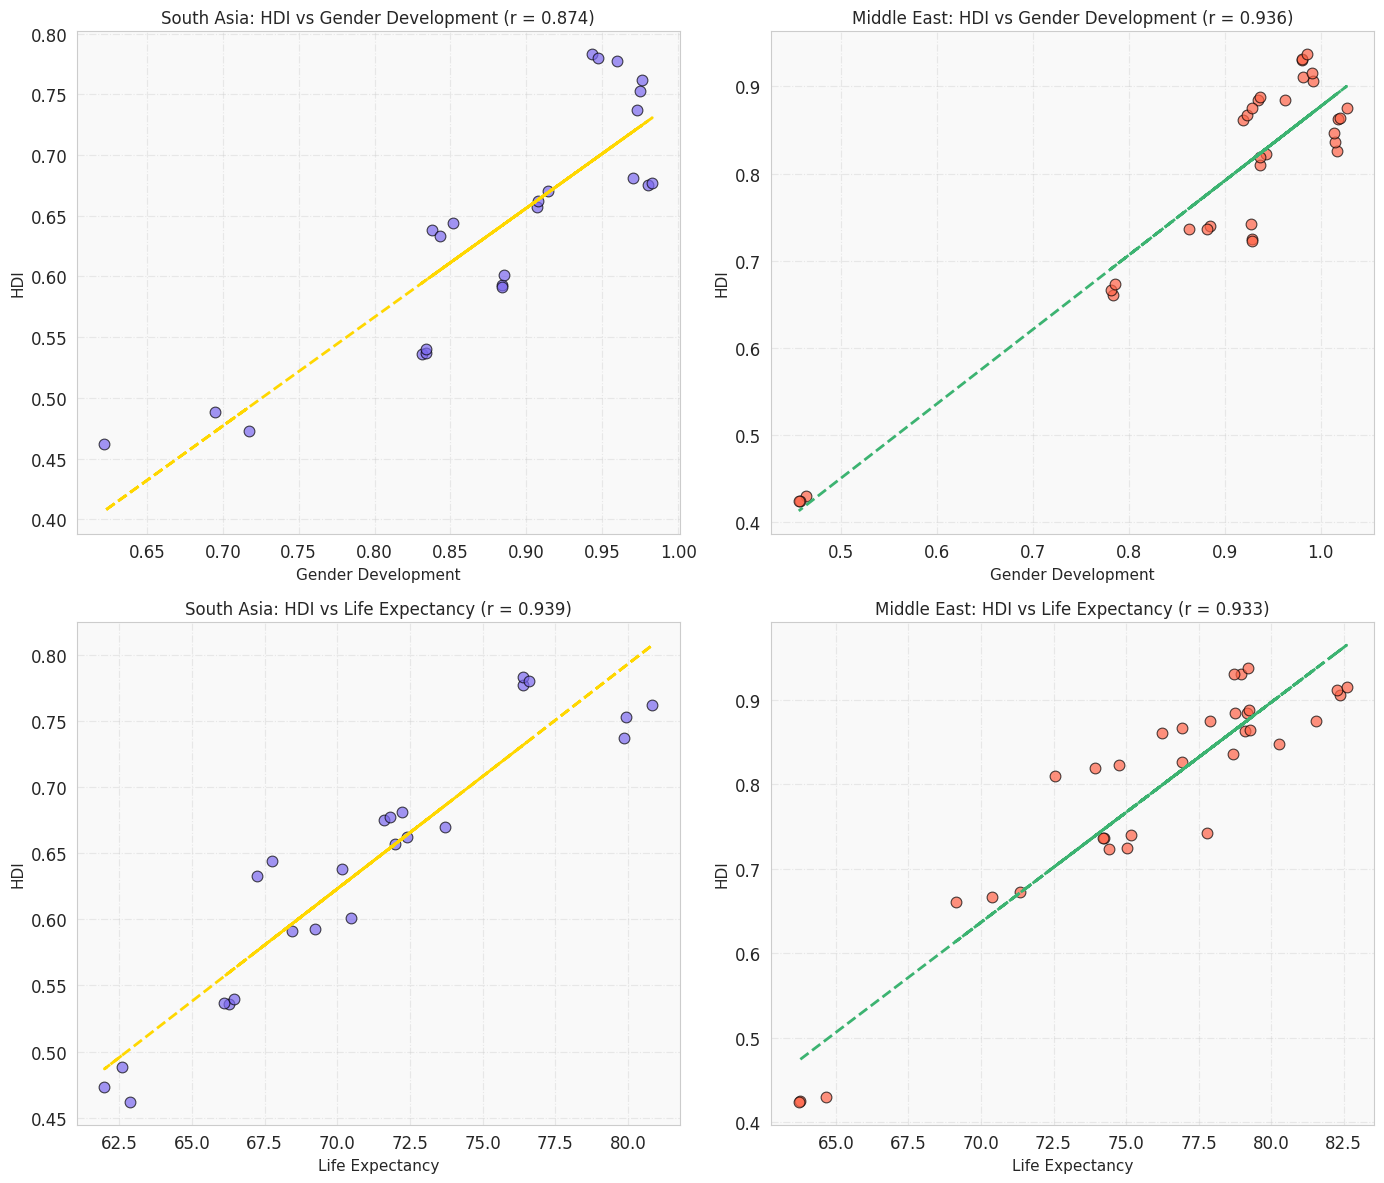

Saved: correlation_analysis_modern.png


In [30]:
'''
TASK 6: Correlation Analysis
Purpose:
- Examine the relationships between selected development metrics and HDI
  in South Asia and Middle East (2020-2022).
- Compute Pearson correlation coefficients and visualize via scatter plots
  with regression lines.
- Metrics analyzed: Gender Development, Life Expectancy.
- Distinct colors differentiate regions and regression lines for clarity.
'''
print("\n" + "="*60)
print("TASK 6: CORRELATION ANALYSIS")
print("="*60)

correlation_metrics = ['gender_development', 'life_expectancy']
available_corr_metrics = [m for m in correlation_metrics if m in hdi_2020_2022.columns]

print(f"Available metrics for correlation: {available_corr_metrics}")

if available_corr_metrics:
    fig, axes = plt.subplots(len(available_corr_metrics), 2, figsize=(14, 6*len(available_corr_metrics)))

    if len(available_corr_metrics) == 1:
        axes = axes.reshape(1, -1)

    for i, metric in enumerate(available_corr_metrics):
        print(f"\n--- Correlation with {metric.replace('_', ' ').title()} ---")

        # South Asia
        sa_data = south_asia_df[['hdi', metric]].dropna()
        if len(sa_data) > 1:
            sa_corr = sa_data['hdi'].corr(sa_data[metric])
            print(f"South Asia: r = {sa_corr:.3f}")

            axes[i, 0].scatter(sa_data[metric], sa_data['hdi'],
                               color='mediumslateblue', alpha=0.7, s=60, edgecolor='black', linewidth=0.8)

            z = np.polyfit(sa_data[metric], sa_data['hdi'], 1)
            p = np.poly1d(z)
            axes[i, 0].plot(sa_data[metric], p(sa_data[metric]), 'gold', linestyle='--', linewidth=2)

            axes[i, 0].set_xlabel(metric.replace('_', ' ').title(), fontsize=11)
            axes[i, 0].set_ylabel('HDI', fontsize=11)
            axes[i, 0].set_title(f'South Asia: HDI vs {metric.replace("_", " ").title()} (r = {sa_corr:.3f})', fontsize=12)
            axes[i, 0].grid(True, linestyle='-.', alpha=0.4)
            axes[i, 0].set_facecolor('#F9F9F9')

        # Middle East
        me_data = middle_east_df[['hdi', metric]].dropna()
        if len(me_data) > 1:
            me_corr = me_data['hdi'].corr(me_data[metric])
            print(f"Middle East: r = {me_corr:.3f}")

            axes[i, 1].scatter(me_data[metric], me_data['hdi'],
                               color='tomato', alpha=0.7, s=60, edgecolor='black', linewidth=0.8)

            z = np.polyfit(me_data[metric], me_data['hdi'], 1)
            p = np.poly1d(z)
            axes[i, 1].plot(me_data[metric], p(me_data[metric]), 'mediumseagreen', linestyle='--', linewidth=2)

            axes[i, 1].set_xlabel(metric.replace('_', ' ').title(), fontsize=11)
            axes[i, 1].set_ylabel('HDI', fontsize=11)
            axes[i, 1].set_title(f'Middle East: HDI vs {metric.replace("_", " ").title()} (r = {me_corr:.3f})', fontsize=12)
            axes[i, 1].grid(True, linestyle='-.', alpha=0.4)
            axes[i, 1].set_facecolor('#F9F9F9')

    plt.tight_layout()
    plt.savefig('correlation_analysis_modern.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: correlation_analysis_modern.png")



TASK 7: OUTLIER DETECTION
Available columns for outlier detection: ['hdi', 'gross_inc_percap']

--- Outliers in Hdi ---
South Asia: 0 outliers detected
Middle East: 3 outliers detected
  Yemen (2020): 0.430
  Yemen (2021): 0.425
  Yemen (2022): 0.424

--- Outliers in Gross Inc Percap ---
South Asia: 0 outliers detected
Middle East: 0 outliers detected


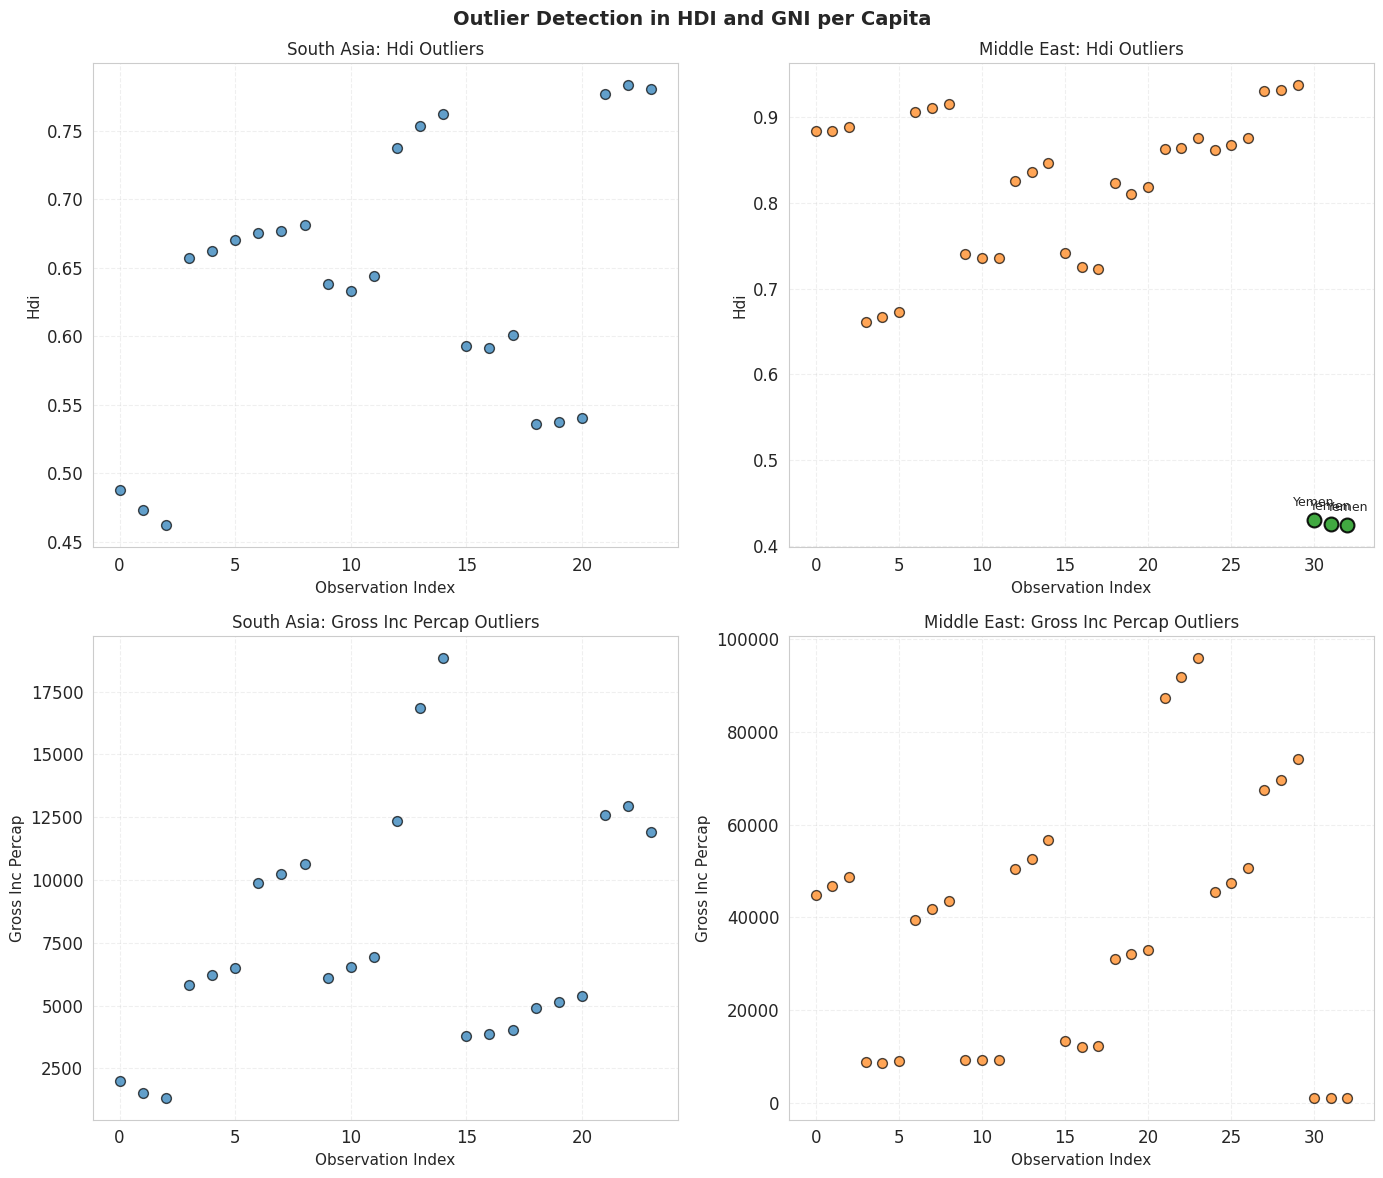

Saved: outlier_detection_modern.png

--- SIGNIFICANCE OF OUTLIERS ---

    Outliers in HDI and GNI per capita indicate:
    - Exceptional performance or challenges
    - Unique economic/social structures
    - Potential data issues
    - Regional impact on averages and disparities
    


In [31]:
'''
TASK 7: Outlier Detection
Purpose:
- Identify outliers in HDI and GNI per capita for South Asia and Middle East (2020-2022)
  using the Interquartile Range (IQR) method.
- Highlight outliers in scatter plots for visual inspection.
- Distinguish normal points and outliers using updated colors.
'''
print("\n" + "="*60)
print("TASK 7: OUTLIER DETECTION")
print("="*60)

def detect_outliers_iqr(df, column):
    if column not in df.columns:
        return pd.Series([False]*len(df))

    data = df[column].dropna()
    if len(data) == 0:
        return pd.Series([False]*len(df))

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (df[column] < lower) | (df[column] > upper)

outlier_cols = ['hdi', 'gross_inc_percap']
available_outlier_cols = [col for col in outlier_cols if col in hdi_2020_2022.columns]

print(f"Available columns for outlier detection: {available_outlier_cols}")

if available_outlier_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    plot_idx = 0

    for col in available_outlier_cols:
        print(f"\n--- Outliers in {col.replace('_', ' ').title()} ---")

        for region_df, region_name, color in [(south_asia_df, 'South Asia', '#1f77b4'),  # Blue
                                              (middle_east_df, 'Middle East', '#ff7f0e')]:  # Orange
            outliers = detect_outliers_iqr(region_df, col)
            count = outliers.sum()
            print(f"{region_name}: {count} outliers detected")
            if count > 0:
                for idx, row in region_df[outliers].iterrows():
                    print(f"  {row['country']} ({row['year']}): {row[col]:.3f}")

            ax = axes[plot_idx]
            normal = region_df[~outliers]
            abnormal = region_df[outliers]

            # Plot normal points
            ax.scatter(range(len(normal)), normal[col], s=50, alpha=0.7, color=color, edgecolor='black')

            # Plot outliers
            if not abnormal.empty:
                ax.scatter(range(len(normal), len(normal)+len(abnormal)), abnormal[col],
                           s=100, color='#2ca02c', edgecolor='black', linewidth=1.5, alpha=0.9)  # Green outliers
                for idx, row in abnormal.iterrows():
                    ax.annotate(row['country'],
                                (len(normal) + list(abnormal.index).index(idx), row[col]),
                                xytext=(0,10), textcoords='offset points', ha='center', fontsize=9)

            ax.set_xlabel('Observation Index', fontsize=11)
            ax.set_ylabel(col.replace('_', ' ').title(), fontsize=11)
            ax.set_title(f'{region_name}: {col.replace("_", " ").title()} Outliers', fontsize=12)
            ax.grid(True, linestyle='--', alpha=0.3)
            plot_idx += 1

    plt.suptitle('Outlier Detection in HDI and GNI per Capita', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outlier_detection_modern.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: outlier_detection_modern.png")

    print("\n--- SIGNIFICANCE OF OUTLIERS ---")
    print("""
    Outliers in HDI and GNI per capita indicate:
    - Exceptional performance or challenges
    - Unique economic/social structures
    - Potential data issues
    - Regional impact on averages and disparities
    """)


In [32]:
print("\n" + "="*70)
print("ANALYSIS SUMMARY")
print("="*70)

print("\nHighlights:")

print("\n1. Regional Data Subsets Created and Stored:")
print("   - HDI_SouthAsia_2020_2022.csv")
print("   - HDI_MiddleEast_2020_2022.csv")

print("\n2. Regional Performance Overview:")
print(f"   - Average HDI for Middle East: {middle_east_mean:.3f}")
print(f"   - Average HDI for South Asia: {south_asia_mean:.3f}")
print(f"   - Difference in HDI: {abs(middle_east_mean - south_asia_mean):.3f}")

print("\n3. Visualizations Generated:")
print("   1. top_bottom_hdi_comparison.png")
print("   2. metric_comparison_regional.png")
print("   3. hdi_distribution_comparison.png")
print("   4. correlation_analysis_regional.png")
print("   5. outlier_detection_modern.png")

print("\n4. Data Availability Summary:")
print(f"   - Number of South Asia countries included: {len(south_asia_countries)}")
print(f"   - Number of Middle East countries included: {len(middle_east_countries)}")
print(f"   - Metrics available for analysis: {len(available_metrics)}")

print("\n5. Suggestions for Further Exploration:")
print("   - Examine specific outlier countries more closely")
print("   - Assess year-to-year trends within each region")
print("   - Explore correlations for policy insights")
print("   - Benchmark against global averages for perspective")

print("\n" + "="*70)
print("PROBLEM 3: ANALYSIS COMPLETED SUCCESSFULLY")
print("="*70)



ANALYSIS SUMMARY

Highlights:

1. Regional Data Subsets Created and Stored:
   - HDI_SouthAsia_2020_2022.csv
   - HDI_MiddleEast_2020_2022.csv

2. Regional Performance Overview:
   - Average HDI for Middle East: 0.789
   - Average HDI for South Asia: 0.640
   - Difference in HDI: 0.149

3. Visualizations Generated:
   1. top_bottom_hdi_comparison.png
   2. metric_comparison_regional.png
   3. hdi_distribution_comparison.png
   4. correlation_analysis_regional.png
   5. outlier_detection_modern.png

4. Data Availability Summary:
   - Number of South Asia countries included: 8
   - Number of Middle East countries included: 14
   - Metrics available for analysis: 3

5. Suggestions for Further Exploration:
   - Examine specific outlier countries more closely
   - Assess year-to-year trends within each region
   - Explore correlations for policy insights
   - Benchmark against global averages for perspective

PROBLEM 3: ANALYSIS COMPLETED SUCCESSFULLY
